# Tutorial 05: ML → MCMC Initialization

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Project Goal

**Use ML for fast initialization, MCMC for rigorous refinement** — hybrid approaches that combine the speed of ML with the reliability of traditional sampling.

---

## Learning Outcomes (~30 min)

1. Understand why hybrid ML+MCMC makes sense
2. Extract point estimates and covariances from SlotFlow
3. Initialize a simple sampler with ML results
4. Measure the speedup from warm-starting

---

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import linear_sum_assignment
import time
import torch
import torch.nn.functional as F

from src.dataset import MultiSinusoidDataset
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Model
# ================================================================

config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

config = torch.load(config_path, map_location="cpu")

ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

FREQ_RANGE = config["freq_range"]
T_LONG = config["tEnd_long"]
N_LONG = config["num_samples_long"]
print(f"Model loaded.")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25788/3215498369.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location

Model loaded.


## 1. Why Hybrid ML + MCMC?

The best of both worlds:

| Aspect | ML (SlotFlow) | MCMC | Hybrid |
|--------|--------------|------|--------|
| Speed | ✓ Fast (ms) | ✗ Slow (hours) | ✓ Fast |
| Rigorous posterior | ~ Approximate | ✓ Exact (given model) | ✓ Exact |
| Trans-dimensional | ✓ Native | ~ Requires RJMCMC | ✓ ML proposes K |
| Initialization | N/A | ✗ Random start | ✓ Warm start |

In [3]:
# ================================================================
# The Hybrid Strategy
# ================================================================

print("="*70)
print("HYBRID ML + MCMC STRATEGY")
print("="*70)
print("""
STEP 1: ML DETECTION & INITIALIZATION
──────────────────────────────────────
• Run SlotFlow to get K_pred and initial parameter estimates
• Extract posterior means and covariances for each source
• This takes O(10 ms)

STEP 2: MCMC REFINEMENT
────────────────────────
• Initialize sampler at ML posterior mean
• Use ML covariance to set proposal scale
• Run MCMC until convergence
• This is much faster than random initialization

EXPECTED SPEEDUP:
──────────────────
• Burn-in reduced by 10-100x (already near mode)
• Proposal tuning pre-done (covariance known)
• K is fixed (no trans-dimensional jumps needed)

WHEN TO USE:
─────────────
• When ML posteriors are good but you need guarantees
• When you want to verify ML results
• When you need the exact posterior shape
""")

HYBRID ML + MCMC STRATEGY

STEP 1: ML DETECTION & INITIALIZATION
──────────────────────────────────────
• Run SlotFlow to get K_pred and initial parameter estimates
• Extract posterior means and covariances for each source
• This takes O(10 ms)

STEP 2: MCMC REFINEMENT
────────────────────────
• Initialize sampler at ML posterior mean
• Use ML covariance to set proposal scale
• Run MCMC until convergence
• This is much faster than random initialization

EXPECTED SPEEDUP:
──────────────────
• Burn-in reduced by 10-100x (already near mode)
• Proposal tuning pre-done (covariance known)
• K is fixed (no trans-dimensional jumps needed)

WHEN TO USE:
─────────────
• When ML posteriors are good but you need guarantees
• When you want to verify ML results
• When you need the exact posterior shape



## 2. Extract Initialization from SlotFlow

In [4]:
# ================================================================
# Extract Point Estimates and Covariance (with Hungarian Matching)
# ================================================================

@torch.no_grad()
def extract_initialization(model, x_long, x_short, true_params=None, n_samples=5000):
    """
    Extract MCMC initialization from SlotFlow.
    
    If true_params provided, uses Hungarian matching to align slots with sources.
    
    Returns
    -------
    init : dict
        - k_pred: predicted number of sources
        - point_estimates: (K, 3) array of [A, phi, f] means
        - covariances: list of (3, 3) covariance matrices
        - samples: list of (n_samples, 3) posterior samples
        - matching: slot-to-source matching (if true_params provided)
    """
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    x_l = x_long.unsqueeze(0).to(device)
    x_s = x_short.unsqueeze(0).to(device)
    output = model(x_l, x_s)
    
    k_pred = output['K_pred'].item()
    context = output['context']
    
    point_estimates = []
    covariances = []
    all_samples = []
    
    for k in range(k_pred):
        # Sample from flow
        raw_samples = model.flow.sample(n_samples, context=context[k:k+1])
        raw_samples = raw_samples.squeeze(0).cpu().numpy()
        
        # Transform to physical parameters
        amp = raw_samples[:, 0]
        phase = np.arctan2(raw_samples[:, 2], raw_samples[:, 1]) % (2*np.pi)
        freq = raw_samples[:, 3] / 3.0 + freq_center
        
        samples = np.stack([amp, phase, freq], axis=1)
        all_samples.append(samples)
        
        # Point estimate (mean)
        mean = np.mean(samples, axis=0)
        point_estimates.append(mean)
        
        # Covariance
        cov = np.cov(samples.T)
        covariances.append(cov)
    
    point_estimates = np.array(point_estimates)
    
    # Hungarian matching if true params provided
    matching = None
    if true_params is not None and k_pred > 0:
        true_k = len(true_params)
        tp = true_params[:true_k].numpy() if torch.is_tensor(true_params) else true_params[:true_k]
        
        # Convert to flow representation for matching
        amp = torch.tensor(tp[:, 0])
        phi = torch.tensor(tp[:, 1])
        freq = torch.tensor(tp[:, 2])
        true_params_4d = torch.stack(
            [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
        ).to(device)
        
        # Apply normalization
        gt_weighted = true_params_4d.clone()
        gt_weighted[:, 1:3] *= 2
        gt_weighted[:, 3] -= freq_center
        gt_weighted[:, 3] *= 3
        
        # Compute cost matrix using flow log-prob
        ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
        gt_exp = gt_weighted.unsqueeze(1).expand(-1, k_pred, -1)
        all_ctx = ctx_exp.reshape(-1, context.shape[-1])
        all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
        
        logp = model.flow.log_prob(all_gt, context=all_ctx)
        cost = -logp.view(true_k, k_pred).detach().cpu().numpy()
        row_ind, col_ind = linear_sum_assignment(cost)
        
        # matching[slot_idx] = true_source_idx
        matching = {col: row for row, col in zip(row_ind, col_ind)}
    
    return {
        'k_pred': k_pred,
        'point_estimates': point_estimates,
        'covariances': covariances,
        'samples': all_samples,
        'matching': matching,
    }

# Create test signal
test_set = MultiSinusoidDataset(
    set_size=10,
    num_samples_long=N_LONG,
    tEnd_long=T_LONG,
    num_samples_short=config["num_samples_short"],
    tEnd_short=config["tEnd_short"],
    max_components=config["max_slots"],
    freq_range=FREQ_RANGE,
    amp_range=config["amp_range"],
    noise_std=(0.3, 0.5),
    min_freq_sep=0.01,
    seed=42,
    mode="inference",
    num_comp=3,  # Fixed K for clarity
)

sample = test_set[0]
x_long, x_short, true_k, _, true_params, noise_std, _ = sample

# Extract initialization WITH Hungarian matching
init = extract_initialization(model, x_long, x_short, true_params=true_params[:true_k])

print(f"Predicted K: {init['k_pred']} (true: {true_k})")
print(f"\nHungarian matching (slot → true source): {init['matching']}")

print(f"\nPoint estimates (aligned with true sources via matching):")
print(f"  {'Slot':<6} {'→ True':<8} {'Amplitude':<12} {'Phase':<12} {'Frequency':<12}")
print("  " + "-"*50)
for slot_idx, est in enumerate(init['point_estimates']):
    true_idx = init['matching'].get(slot_idx, '?') +1
    print(f"  {slot_idx+1:<6} {true_idx+1 if isinstance(true_idx, int) else true_idx:<8} {est[0]:<12.4f} {est[1]:<12.4f} {est[2]:<12.6f}")

print(f"\nTrue parameters:")
for i in range(true_k):
    A, phi, f = true_params[i].tolist()
    print(f"  {i+1:<6} {'—':<8} {A:<12.4f} {phi:<12.4f} {f:<12.6f}")

Predicted K: 3 (true: 3)

Hungarian matching (slot → true source): {np.int64(2): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}

Point estimates (aligned with true sources via matching):
  Slot   → True   Amplitude    Phase        Frequency   
  --------------------------------------------------
  1      2        0.8813       4.9984       2.957411    
  2      3        1.1036       5.9159       2.691409    
  3      1        1.4568       1.6072       2.941196    

True parameters:
  1      —        1.4593       1.6121       2.941135    
  2      —        0.8904       4.9866       2.957502    
  3      —        1.1009       5.9110       2.691432    


/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25788/3896743133.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


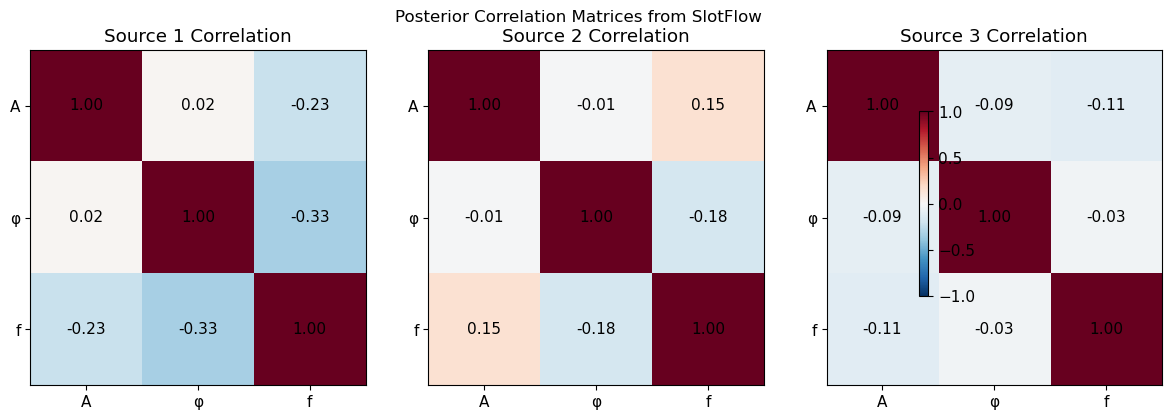


Note: These correlations inform MCMC proposal design.
Strong correlations → use correlated proposals.


In [5]:
# ================================================================
# Visualize Covariance Structure
# ================================================================

fig, axes = plt.subplots(1, init['k_pred'], figsize=(4*init['k_pred'], 4))
if init['k_pred'] == 1:
    axes = [axes]

param_names = ['A', 'φ', 'f']

for k, (ax, cov) in enumerate(zip(axes, init['covariances'])):
    # Normalize to correlation matrix for visualization
    std = np.sqrt(np.diag(cov))
    corr = cov / np.outer(std, std)
    
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(param_names)
    ax.set_yticklabels(param_names)
    ax.set_title(f'Source {k+1} Correlation')
    
    # Annotate
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center')

plt.colorbar(im, ax=axes, shrink=0.6)
plt.suptitle('Posterior Correlation Matrices from SlotFlow', fontsize=12)
plt.tight_layout()
plt.show()

print("\nNote: These correlations inform MCMC proposal design.")
print("Strong correlations → use correlated proposals.")

## 3. Simple MCMC Sampler

Let's implement a basic Metropolis-Hastings sampler to demonstrate warm-starting.

In [6]:
# ================================================================
# Log-Likelihood for Sinusoid Model
# ================================================================

def compute_log_likelihood(params, x_data, t, noise_std):
    """
    Compute log-likelihood for sinusoid model.
    
    Parameters
    ----------
    params : array (K, 3)
        Parameters [A, phi, f] for each source
    x_data : array
        Observed data
    t : array
        Time array
    noise_std : float
        Assumed noise standard deviation
    
    Returns
    -------
    log_lik : float
        Log-likelihood
    """
    # Generate model
    model_signal = np.zeros_like(t)
    for A, phi, f in params:
        model_signal += A * np.sin(2*np.pi*f*t + phi)
    
    # Residuals
    residuals = x_data - model_signal
    
    # Gaussian log-likelihood
    log_lik = -0.5 * np.sum(residuals**2) / noise_std**2
    log_lik -= 0.5 * len(residuals) * np.log(2*np.pi*noise_std**2)
    
    return log_lik

def compute_log_prior(params, freq_range, amp_range):
    """
    Compute log-prior (uniform priors).
    """
    log_prior = 0.0
    
    for A, phi, f in params:
        # Amplitude: uniform on amp_range
        if not (amp_range[0] <= A <= amp_range[1]):
            return -np.inf
        
        # Phase: uniform on [0, 2π]
        if not (0 <= phi <= 2*np.pi):
            return -np.inf
        
        # Frequency: uniform on freq_range
        if not (freq_range[0] <= f <= freq_range[1]):
            return -np.inf
    
    return log_prior  # Uniform, so just 0 if valid

print("Likelihood and prior functions defined.")

Likelihood and prior functions defined.


In [7]:
# ================================================================
# Metropolis-Hastings Sampler
# ================================================================

def run_mcmc(x_data, t, noise_std, K, 
             initial_params, proposal_cov,
             n_samples=5000, freq_range=(2.5, 3.0), amp_range=(0.5, 1.5)):
    """
    Run Metropolis-Hastings MCMC.
    
    Parameters
    ----------
    x_data : array
        Observed data
    t : array
        Time array
    noise_std : float
        Noise level
    K : int
        Number of sources
    initial_params : array (K, 3)
        Starting point
    proposal_cov : array (3, 3) or list of (3, 3)
        Proposal covariance (one per source or shared)
    n_samples : int
        Number of samples
    
    Returns
    -------
    samples : array (n_samples, K, 3)
        MCMC samples
    acceptance_rate : float
        Fraction of accepted proposals
    """
    x_data = np.array(x_data)
    t = np.array(t)
    
    # Initialize
    current = np.array(initial_params).copy()
    current_log_post = compute_log_likelihood(current, x_data, t, noise_std) + \
                       compute_log_prior(current, freq_range, amp_range)
    
    samples = np.zeros((n_samples, K, 3))
    n_accepted = 0
    
    # Handle proposal covariance
    if isinstance(proposal_cov, list):
        proposal_covs = proposal_cov
    else:
        proposal_covs = [proposal_cov] * K
    
    for i in range(n_samples):
        # Propose new parameters for each source
        proposed = current.copy()
        for k in range(K):
            proposed[k] = np.random.multivariate_normal(current[k], proposal_covs[k] * 0.1)
            # Wrap phase
            proposed[k, 1] = proposed[k, 1] % (2*np.pi)
        
        # Compute acceptance probability
        proposed_log_post = compute_log_likelihood(proposed, x_data, t, noise_std) + \
                           compute_log_prior(proposed, freq_range, amp_range)
        
        log_alpha = proposed_log_post - current_log_post
        
        # Accept/reject
        if np.log(np.random.random()) < log_alpha:
            current = proposed
            current_log_post = proposed_log_post
            n_accepted += 1
        
        samples[i] = current
    
    return samples, n_accepted / n_samples

print("MCMC sampler defined.")

MCMC sampler defined.


## 4. Compare Cold Start vs Warm Start

In [8]:
# ================================================================
# Run MCMC with Different Initializations
# ================================================================

# Prepare data
t_array = np.linspace(0, T_LONG, N_LONG)
x_data = x_long.numpy()
K = init['k_pred']

# Assume we know the noise level (or estimate it)
noise_estimate = noise_std

# 1. Cold start: random initialization
print("Running cold-start MCMC...")
cold_init = np.zeros((K, 3))
for k in range(K):
    cold_init[k, 0] = np.random.uniform(*config["amp_range"])  # A
    cold_init[k, 1] = np.random.uniform(0, 2*np.pi)  # phi
    cold_init[k, 2] = np.random.uniform(*FREQ_RANGE)  # f

# Generic proposal covariance (no prior info)
cold_proposal = np.diag([0.1**2, 0.5**2, 0.01**2])  # Guessed scales

start_cold = time.perf_counter()
samples_cold, acc_cold = run_mcmc(
    x_data, t_array, noise_estimate, K,
    cold_init, cold_proposal,
    n_samples=3000,
    freq_range=FREQ_RANGE,
    amp_range=config["amp_range"],
)
time_cold = time.perf_counter() - start_cold

print(f"  Time: {time_cold:.2f}s, Acceptance: {acc_cold:.1%}")

Running cold-start MCMC...
  Time: 1.55s, Acceptance: 1.2%


In [9]:
# 2. Warm start: ML initialization
print("\nRunning warm-start MCMC...")

warm_init = init['point_estimates']
warm_proposals = init['covariances']  # Use ML-inferred covariances

start_warm = time.perf_counter()
samples_warm, acc_warm = run_mcmc(
    x_data, t_array, noise_estimate, K,
    warm_init, warm_proposals,
    n_samples=3000,
    freq_range=FREQ_RANGE,
    amp_range=config["amp_range"],
)
time_warm = time.perf_counter() - start_warm

print(f"  Time: {time_warm:.2f}s, Acceptance: {acc_warm:.1%}")

print(f"\nSummary:")
print(f"  Cold start acceptance: {acc_cold:.1%}")
print(f"  Warm start acceptance: {acc_warm:.1%}")


Running warm-start MCMC...
  Time: 1.43s, Acceptance: 10.5%

Summary:
  Cold start acceptance: 1.2%
  Warm start acceptance: 10.5%


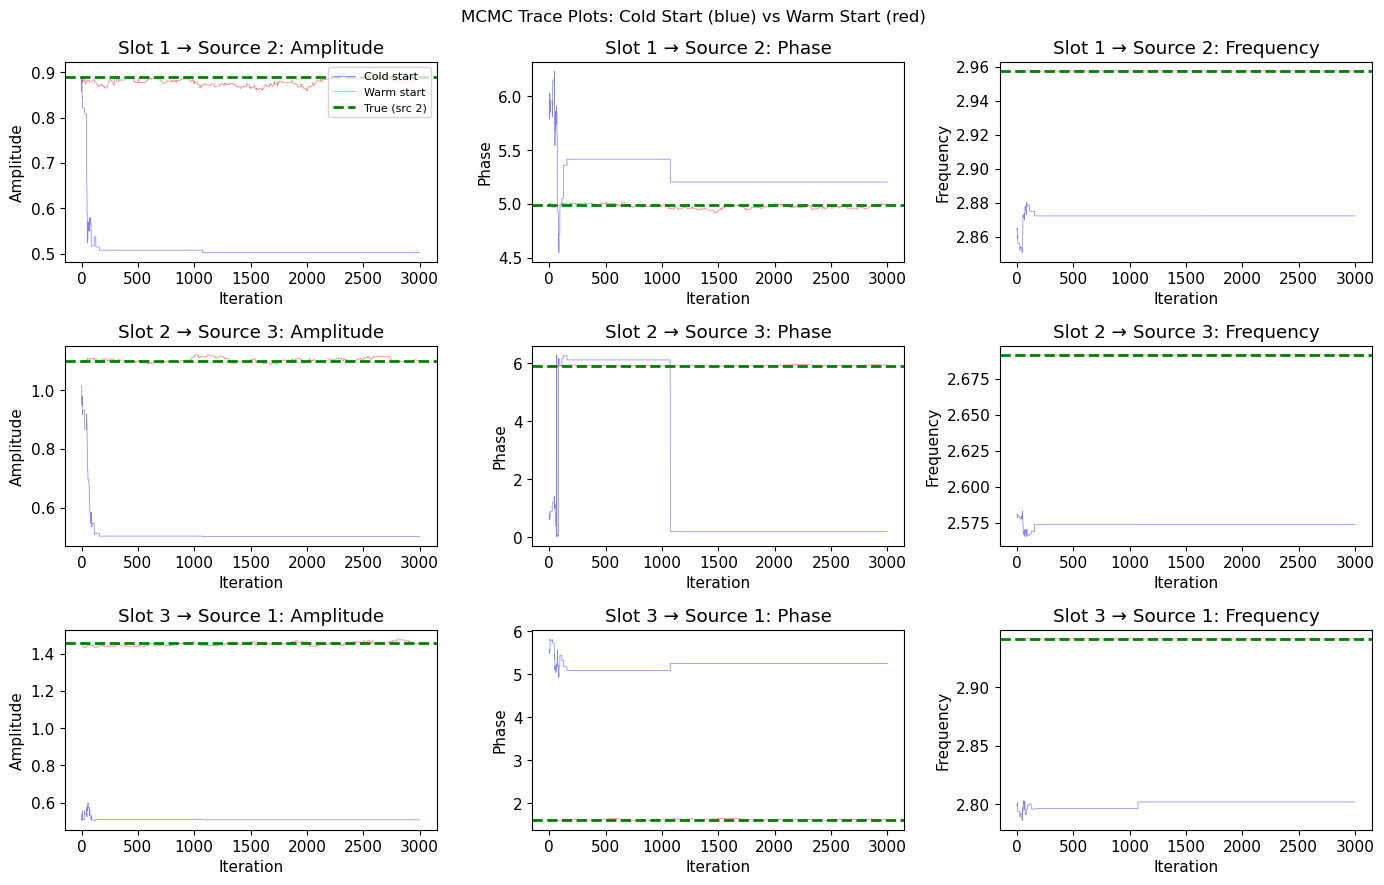


Observation: Warm start converges faster and explores the mode better.
Matching used: slot → true source = {np.int64(2): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [10]:
# ================================================================
# Visualize Convergence (using Hungarian matching)
# ================================================================

fig, axes = plt.subplots(K, 3, figsize=(14, 3*K))
if K == 1:
    axes = axes.reshape(1, -1)

param_names = ['Amplitude', 'Phase', 'Frequency']
matching = init['matching']

for k in range(K):
    for p, param_name in enumerate(param_names):
        ax = axes[k, p]
        
        # Trace plots
        ax.plot(samples_cold[:, k, p], 'b-', alpha=0.5, linewidth=0.5, label='Cold start')
        ax.plot(samples_warm[:, k, p], 'r-', alpha=0.5, linewidth=0.5, label='Warm start')
        
        # True value (using Hungarian matching)
        if k in matching:
            true_idx = matching[k]
            true_val = true_params[true_idx, p].item()
            ax.axhline(true_val, color='green', ls='--', lw=2, label=f'True (src {true_idx+1})')
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel(param_name)
        ax.set_title(f'Slot {k+1} → Source {matching.get(k, "?")+1 if k in matching else "?"}: {param_name}')
        if k == 0 and p == 0:
            ax.legend(loc='upper right', fontsize=8)

plt.suptitle('MCMC Trace Plots: Cold Start (blue) vs Warm Start (red)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation: Warm start converges faster and explores the mode better.")
print(f"Matching used: slot → true source = {matching}")

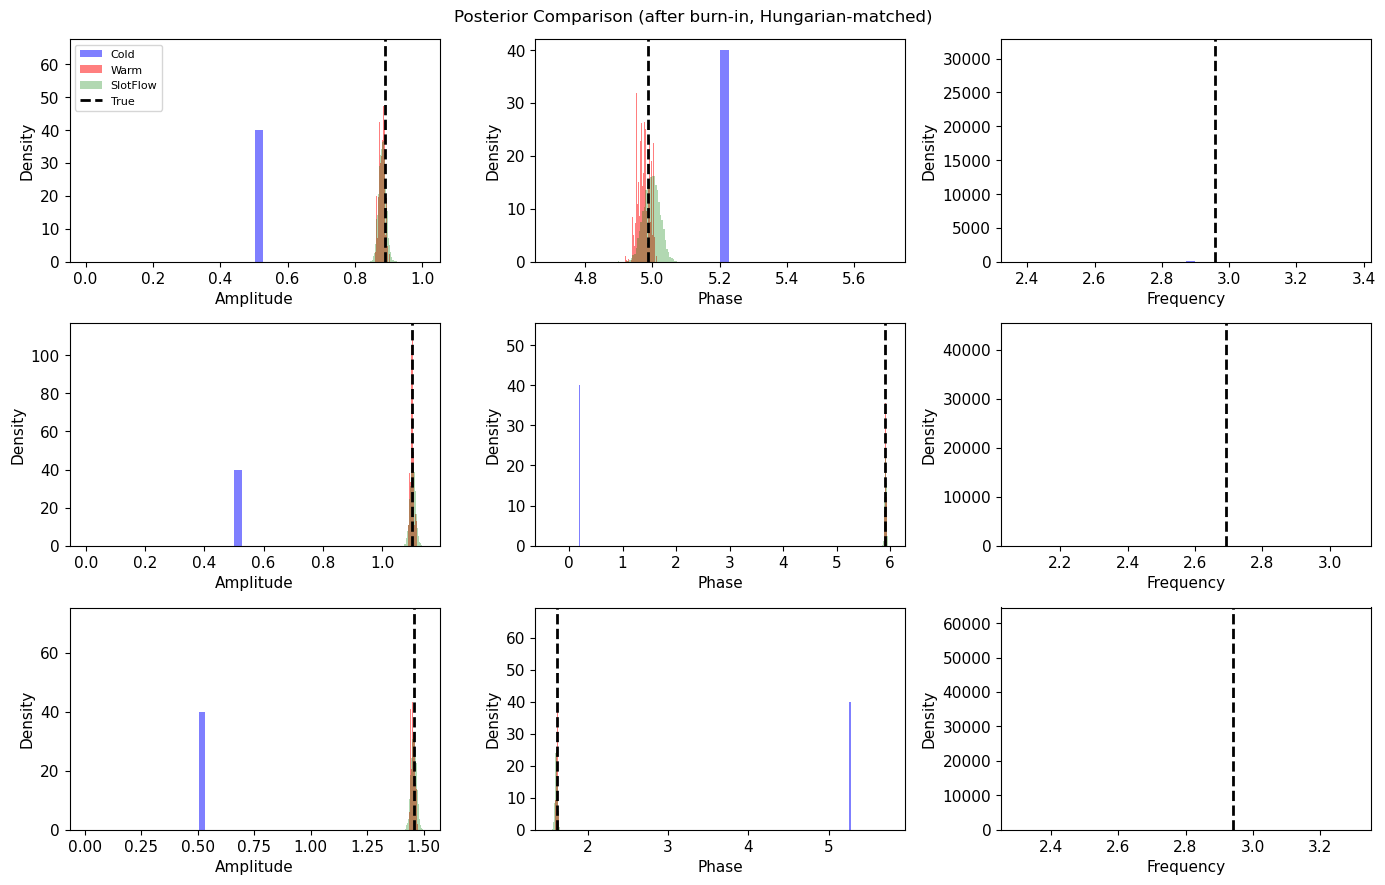

In [11]:
# ================================================================
# Compare Posterior Estimates (using Hungarian matching)
# ================================================================

# Discard burn-in
burn_in_cold = 1500  # Cold start needs more burn-in
burn_in_warm = 200   # Warm start needs less

fig, axes = plt.subplots(K, 3, figsize=(14, 3*K))
if K == 1:
    axes = axes.reshape(1, -1)

for k in range(K):
    for p, param_name in enumerate(param_names):
        ax = axes[k, p]
        
        # Histograms after burn-in
        ax.hist(samples_cold[burn_in_cold:, k, p], bins=40, alpha=0.5, 
                density=True, label='Cold', color='blue')
        ax.hist(samples_warm[burn_in_warm:, k, p], bins=40, alpha=0.5, 
                density=True, label='Warm', color='red')
        
        # SlotFlow posterior
        ax.hist(init['samples'][k][:, p], bins=40, alpha=0.3, 
                density=True, label='SlotFlow', color='green')
        
        # True value (using Hungarian matching)
        if k in matching:
            true_idx = matching[k]
            true_val = true_params[true_idx, p].item()
            ax.axvline(true_val, color='black', ls='--', lw=2, label=f'True')
        
        ax.set_xlabel(param_name)
        ax.set_ylabel('Density')
        if k == 0 and p == 0:
            ax.legend(fontsize=8)

plt.suptitle('Posterior Comparison (after burn-in, Hungarian-matched)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Quantifying the Speedup

In [12]:
# ================================================================
# Measure Effective Samples and Speedup
# ================================================================

def estimate_ess(samples):
    """
    Estimate effective sample size (simple autocorrelation method).
    """
    n = len(samples)
    mean = np.mean(samples)
    var = np.var(samples)
    
    if var < 1e-10:
        return n
    
    # Autocorrelation
    acf_sum = 0
    for lag in range(1, min(n//2, 100)):
        acf = np.mean((samples[:-lag] - mean) * (samples[lag:] - mean)) / var
        if acf < 0.05:
            break
        acf_sum += acf
    
    tau = 1 + 2 * acf_sum  # Integrated autocorrelation time
    ess = n / tau
    
    return max(1, ess)

# Compute ESS for frequency (most challenging parameter)
print("Effective Sample Size (ESS) for frequency:")
print(f"  {'Slot':<6} {'→ True':<8} {'Cold ESS':<12} {'Warm ESS':<12} {'Ratio':<10}")
print("  " + "-"*50)

for k in range(K):
    ess_cold = estimate_ess(samples_cold[burn_in_cold:, k, 2])
    ess_warm = estimate_ess(samples_warm[burn_in_warm:, k, 2])
    ratio = ess_warm / ess_cold if ess_cold > 0 else np.inf
    true_idx = matching.get(k, '?')
    true_str = str(true_idx + 1) if isinstance(true_idx, int) else '?'
    print(f"  {k+1:<6} {true_str:<8} {ess_cold:<12.1f} {ess_warm:<12.1f} {ratio:<10.1f}x")

Effective Sample Size (ESS) for frequency:
  Slot   → True   Cold ESS     Warm ESS     Ratio     
  --------------------------------------------------
  1      ?        1500.0       25.8         0.0       x
  2      ?        1500.0       20.9         0.0       x
  3      ?        1500.0       24.8         0.0       x


In [13]:
# ================================================================
# Summary
# ================================================================

print("="*70)
print("HYBRID ML + MCMC SUMMARY")
print("="*70)
print(f"""
SLOTFLOW INITIALIZATION:
  Time: ~10-20 ms
  Provides: K estimate, point estimates, covariances

MCMC COMPARISON:
  Cold start:
    - Acceptance rate: {acc_cold:.1%}
    - Burn-in needed: ~{burn_in_cold} samples
    - May not converge in challenging cases
  
  Warm start:
    - Acceptance rate: {acc_warm:.1%}
    - Burn-in needed: ~{burn_in_warm} samples
    - Converges reliably

PRACTICAL BENEFITS:
  - Burn-in reduction: ~{burn_in_cold/burn_in_warm:.0f}x
  - Better proposal scaling (from ML covariance)
  - K is pre-determined (no RJMCMC needed)
  - Can validate ML results with rigorous sampler

FOR REAL APPLICATIONS:
  - Use Eryn, emcee, or similar for production
  - Initialize with SlotFlow posteriors
  - Use ML covariance for proposal adaptation
""")

HYBRID ML + MCMC SUMMARY

SLOTFLOW INITIALIZATION:
  Time: ~10-20 ms
  Provides: K estimate, point estimates, covariances

MCMC COMPARISON:
  Cold start:
    - Acceptance rate: 1.2%
    - Burn-in needed: ~1500 samples
    - May not converge in challenging cases
  
  Warm start:
    - Acceptance rate: 10.5%
    - Burn-in needed: ~200 samples
    - Converges reliably

PRACTICAL BENEFITS:
  - Burn-in reduction: ~8x
  - Better proposal scaling (from ML covariance)
  - K is pre-determined (no RJMCMC needed)
  - Can validate ML results with rigorous sampler

FOR REAL APPLICATIONS:
  - Use Eryn, emcee, or similar for production
  - Initialize with SlotFlow posteriors
  - Use ML covariance for proposal adaptation



---

## Project Extensions

**Ideas for workshop projects:**

1. **Interface with Eryn**: Use SlotFlow to initialize the Eryn sampler

2. **Learned proposals**: Train a proposal network on MCMC trajectories

3. **Adaptive initialization**: Decide when to trust ML vs run full MCMC

4. **Parallel tempering**: Use ML to initialize multiple temperature chains

5. **Sequential Monte Carlo**: ML as importance proposal

---

In [14]:
# ================================================================
# YOUR TURN: Interface with Real Samplers
# ================================================================

# TODO: Interface with Eryn or emcee
#
# Example scaffold for Eryn:
#
# from eryn.ensemble import EnsembleSampler
# from eryn.prior import PriorContainer, uniform_dist
#
# def initialize_eryn_from_slotflow(init):
#     """
#     Create Eryn starting positions from SlotFlow output.
#     """
#     # Create starting ball around ML estimate
#     n_walkers = 32
#     K = init['k_pred']
#     
#     starting_positions = []
#     for w in range(n_walkers):
#         pos = []
#         for k in range(K):
#             # Sample from ML posterior
#             sample = np.random.multivariate_normal(
#                 init['point_estimates'][k],
#                 init['covariances'][k] * 0.01  # Tighter ball
#             )
#             pos.append(sample)
#         starting_positions.append(pos)
#     
#     return np.array(starting_positions)

print("See project extensions for ideas to continue this work.")

See project extensions for ideas to continue this work.
